# Inspection Mode

This notebook is one chapter of the runnable `KnottedGraph` user guide.  It is
generated into `User_guide/03_inspection_mode.ipynb` so users can open the specific workflow
they need without navigating one very large notebook.

- self-contained after the shared setup cells


## 0. Setup, Preflight, And Shared Plot Style

The whole notebook uses the same visual convention:

- blue: surfaces, skeleton points, and graph edges;
- red: graph vertices;
- black axes;
- paper notation: `Upsilon(G; Y)`.

The helper functions in this section remove repeated plotting boilerplate from
the rest of the notebook.  This is also the library-level pattern worth
promoting later into public visualization helpers.


In [1]:
from pathlib import Path
import sys
import importlib.util
import os
import tempfile

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DOC_ROOT = PROJECT_ROOT / "doc"
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "knottedgraph-mpl"))

print("project paths configured")
for package in ["numpy", "networkx", "sympy", "plotly", "matplotlib", "pyvista"]:
    print(f"{package:10s} = {importlib.util.find_spec(package) is not None}")


project paths configured
numpy      = True
networkx   = True
sympy      = True
plotly     = True
matplotlib = True
pyvista    = True


In [2]:
import math
import time

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import sympy as sp
from IPython.display import Math, display

from knotted_graph.projection import (
    compute_yamada_polynomial,
    sample_projections,
    select_projection,
)
from knotted_graph.visualization import plot_3D_graph_plotly

BLUE = "#1f77b4"
RED = "#d62728"
CAMERA = dict(eye=dict(x=1.45, y=1.55, z=1.18))
pio.renderers.default = "notebook_connected"
Y = sp.Symbol("Y")
kx, ky, kz = sp.symbols("k_x k_y k_z", real=True)


def axis_style():
    return dict(
        visible=True,
        title="",
        showticklabels=False,
        showbackground=False,
        showgrid=False,
        zeroline=False,
        showline=True,
        linecolor="black",
        linewidth=2,
    )


def apply_kg_layout(fig, *, width=760, height=620):
    fig.update_layout(
        title=None,
        width=width,
        height=height,
        margin=dict(l=0, r=0, t=0, b=0),
        scene=dict(
            xaxis=axis_style(),
            yaxis=axis_style(),
            zaxis=axis_style(),
            aspectmode="data",
            camera=CAMERA,
        ),
    )
    return fig


def plot_surface_polydata(surface, *, opacity=0.58):
    mesh = surface.triangulate()
    faces = mesh.faces.reshape(-1, 4)[:, 1:]
    pts = mesh.points
    fig = go.Figure(
        go.Mesh3d(
            x=pts[:, 0],
            y=pts[:, 1],
            z=pts[:, 2],
            i=faces[:, 0],
            j=faces[:, 1],
            k=faces[:, 2],
            color=BLUE,
            opacity=opacity,
        )
    )
    return apply_kg_layout(fig)


def plot_points_3d(points, *, size=3):
    points = np.asarray(points)
    fig = go.Figure(
        go.Scatter3d(
            x=points[:, 0],
            y=points[:, 1],
            z=points[:, 2],
            mode="markers",
            marker=dict(size=size, color=BLUE),
        )
    )
    return apply_kg_layout(fig)


def plot_graph_kg(graph):
    return apply_kg_layout(plot_3D_graph_plotly(graph))


def print_upsilon(label, expr):
    print(f"Upsilon({label}; Y) = {sp.expand(expr)}")


def display_bloch_vector(label, components):
    display(Math(label + r"=" + sp.latex(sp.Matrix(components))))


print("shared plotting and notation helpers ready")


shared plotting and notation helpers ready


## 3. Inspection Mode: Every Intermediate Object

This section follows the paper's Fig. 1 logic with an awesome non-Hermitian
surface.  The inspected stages are surface, filled mask, skeleton, raw graph,
leaf removal, chain collapse, short-edge contraction, smoothing, planar
diagram, PD code, and invariant.


In [3]:
from skimage import morphology

from knotted_graph.applications.nodal import NodalSkeleton
from knotted_graph.applications.nodal.models import awesome_bloch_vector, hopf_link_bloch_vector
from knotted_graph.core import (
    contract_short_edges,
    idx_to_coord,
    remove_leaf_nodes,
    simplify_edges,
    smooth_edges,
)
from knotted_graph.extraction import skeleton_image_to_graph


def graph_indices_to_kspace(index_graph, skeleton):
    graph_kspace = nx.MultiGraph()
    for node, data in index_graph.nodes(data=True):
        attrs = dict(data)
        attrs["pos"] = idx_to_coord(attrs["pos"], spacing=skeleton.spacing, origin=skeleton.origin)
        graph_kspace.add_node(node, **attrs)

    for u, v, key, data in index_graph.edges(keys=True, data=True):
        attrs = dict(data)
        if attrs.get("pts") is not None:
            attrs["pts"] = idx_to_coord(attrs["pts"], spacing=skeleton.spacing, origin=skeleton.origin)
        graph_kspace.add_edge(u, v, key=key, **attrs)

    graph_kspace.graph.update(index_graph.graph)
    return graph_kspace

kx, ky, kz = sp.symbols("k_x k_y k_z", real=True)
inspection_gamma = 0.48
inspection_dimension = 72
inspection_model = awesome_bloch_vector(inspection_gamma, k_symbols=(kx, ky, kz))
display_bloch_vector(r"\vec d_{\mathrm{awesome}}(\mathbf{k})", inspection_model)
ske = NodalSkeleton(
    inspection_model,
    k_symbols=(kx, ky, kz),
    span=((-np.pi, np.pi), (-np.pi, np.pi), (-np.pi, np.pi)),
    dimension=inspection_dimension,
    axis_scale=(1.0, 1.0, 1.0),
)

surface = ske.exceptional_surface_pv.connectivity("largest")
filled_mask = ske._interior_mask
skeleton_image = morphology.skeletonize(filled_mask, method="lee")

raw_graph_index = skeleton_image_to_graph(skeleton_image)
leaf_removed_graph_index = remove_leaf_nodes(raw_graph_index)
chain_collapsed_graph_index = simplify_edges(leaf_removed_graph_index)

raw_graph = graph_indices_to_kspace(raw_graph_index, ske)
leaf_removed_graph = graph_indices_to_kspace(leaf_removed_graph_index, ske)
chain_collapsed_graph = graph_indices_to_kspace(chain_collapsed_graph_index, ske)
contracted_graph = contract_short_edges(chain_collapsed_graph, min_length=0.40)
processed_graph = smooth_edges(contracted_graph, epsilon=0.08, copy=True)

rng = np.random.default_rng(5)
mask_indices = np.column_stack(np.where(filled_mask))
mask_indices = mask_indices[
    rng.choice(len(mask_indices), size=min(4500, len(mask_indices)), replace=False)
]
filled_mask_points = idx_to_coord(mask_indices, spacing=ske.spacing, origin=ske.origin)
skeleton_points = idx_to_coord(
    np.column_stack(np.where(skeleton_image)),
    spacing=ske.spacing,
    origin=ske.origin,
)

candidate_projections = sorted(
    sample_projections(processed_graph, num_rotation_samples=16),
    key=lambda candidate: (
        "X[" not in candidate.pd_code,
        candidate.num_crossings == 0,
        candidate.num_crossings,
        candidate.rotation_angles,
    ),
)
projection_inspection = candidate_projections[0]
inspection_result = compute_yamada_polynomial(
    processed_graph,
    Y,
    rotation_angles=projection_inspection.rotation_angles,
    return_result=True,
    n_jobs=1,
)

stage_graphs = [
    ("raw graph", raw_graph),
    ("leaf removal", leaf_removed_graph),
    ("chain collapse", chain_collapsed_graph),
    ("edge contraction", contracted_graph),
    ("smoothing", processed_graph),
]

print("input = awesome_bloch_vector(gamma=0.48)")
print("dimension =", inspection_dimension)
print("surface_points_cells =", (surface.n_points, surface.n_cells))
print("filled_mask_voxels =", int(filled_mask.sum()))
print("skeleton_voxels =", int(skeleton_image.sum()))
for name, stage_graph in stage_graphs:
    print(
        f"{name:16s}",
        "nodes_edges =",
        (stage_graph.number_of_nodes(), stage_graph.number_of_edges()),
        "degrees =",
        sorted(dict(stage_graph.degree()).values()),
    )
print("projection_crossings =", projection_inspection.num_crossings)
print_upsilon("G_awesome_inspection", inspection_result.polynomial)


<IPython.core.display.Math object>

input = awesome_bloch_vector(gamma=0.48)
dimension = 72
surface_points_cells = (11810, 23624)
filled_mask_voxels = 15886
skeleton_voxels = 556
raw graph        nodes_edges = (38, 39) degrees = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 5]
leaf removal     nodes_edges = (12, 15) degrees = [2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3]
chain collapse   nodes_edges = (6, 9) degrees = [3, 3, 3, 3, 3, 3]
edge contraction nodes_edges = (5, 7) degrees = [2, 3, 3, 3, 3]
smoothing        nodes_edges = (5, 7) degrees = [2, 3, 3, 3, 3]
projection_crossings = 2
Upsilon(G_awesome_inspection; Y) = -Y**6 - Y**5 - 3*Y**4 - 2*Y**3 - 3*Y**2 - Y - 1


In [4]:
fig = plot_surface_polydata(surface, opacity=0.58)
fig.show()


In [5]:
fig = plot_points_3d(filled_mask_points, size=2)
fig.show()


In [6]:
fig = plot_points_3d(skeleton_points, size=3)
fig.show()


In [7]:
fig = plot_graph_kg(raw_graph)
fig.show()


In [8]:
fig = plot_graph_kg(leaf_removed_graph)
fig.show()


In [9]:
fig = plot_graph_kg(chain_collapsed_graph)
fig.show()


In [10]:
fig = plot_graph_kg(contracted_graph)
fig.show()


In [11]:
fig = plot_graph_kg(processed_graph)
fig.show()


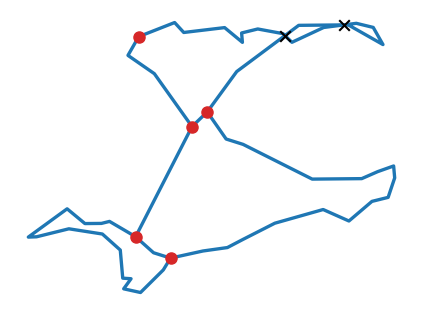

In [12]:
fig, ax = plt.subplots(figsize=(5.2, 4.4))
for arc in projection_inspection.arcs:
    ax.plot(*arc.line.xy, color=BLUE, linewidth=2.4)
for vertex in projection_inspection.vertices:
    ax.scatter(*vertex.point.xy, color=RED, s=64, zorder=3)
for crossing in projection_inspection.crossings:
    ax.scatter(*crossing.point.xy, marker="x", color="black", s=58, zorder=4)
ax.set_aspect("equal")
ax.axis("off")
plt.show()


In [13]:
print(f"rotation_angles = {tuple(round(a, 2) for a in projection_inspection.rotation_angles)}")
print(f"crossings = {projection_inspection.num_crossings}")
print(f"pd_code = {projection_inspection.pd_code}")
print("vertices =", [(v.id, v.key) for v in projection_inspection.vertices])
print(
    "crossing_points =",
    [(x.id, tuple(round(c, 3) for c in tuple(x.point.coords)[0])) for x in projection_inspection.crossings],
)
print(
    "arcs =",
    [(arc.id, arc.start_type, arc.start_id, arc.end_type, arc.end_id) for arc in projection_inspection.arcs],
)


rotation_angles = (-84.98, 81.01, 0.0)
crossings = 2
pd_code = V[1,0,2];V[8,1,7];V[7,6];V[9,0,10];V[10,8,9];X[2,5,3,6]
vertices = [(0, 0), (1, 1), (2, 2), (3, 3), (4, 5)]
crossing_points = [(0, (0.941, 1.145)), (1, (1.575, 1.26))]
arcs = [(0, 'v', 0, 'v', 3), (1, 'v', 0, 'v', 1), (2, 'v', 0, 'x', 0), (3, 'x', 0, 'x', 1), (4, 'x', 1, 'x', 1), (5, 'x', 1, 'x', 0), (6, 'x', 0, 'v', 2), (7, 'v', 1, 'v', 2), (8, 'v', 1, 'v', 4), (9, 'v', 3, 'v', 4), (10, 'v', 3, 'v', 4)]


The inspection output is deliberately verbose.  It gives the user enough
information to debug the exact diagram used downstream: the selected rotation,
crossings, vertices, arcs, and PD-code string.  The graph sequence also shows
which cleanup operation changes the skeleton at each stage.


### 3.1 The Same Pipeline Through The High-Level Convenience Method

The previous cells expose the intermediate objects one by one.  When a user
only wants the standard simplified graph, the high-level method wraps the same
core operations: skeleton image to graph, leaf removal, chain collapse, and
edge smoothing.


In [14]:
standard_graph = ske.skeleton_graph(simplify=True, smooth_epsilon=2)
standard_graph_kspace = graph_indices_to_kspace(standard_graph, ske)

print("standard high-level graph =", (standard_graph_kspace.number_of_nodes(), standard_graph_kspace.number_of_edges()))
print("manual processed graph =", (processed_graph.number_of_nodes(), processed_graph.number_of_edges()))


standard high-level graph = (6, 9)
manual processed graph = (5, 7)


In [15]:
fig = plot_graph_kg(standard_graph_kspace)
fig.show()


Publication-grid exports with panel letters and compressed PDF/SVG/PNG output
are deliberately separate from this tutorial.  The reusable library objects are
the generated surface, mask, skeleton, graphs, projection, PD code, and
polynomial displayed above.
